In [ ]:
# ==================================================================================
# UNIFIED STOCK DECISION SYSTEM
# Combines: DLinear Price Prediction + FinBERT Sentiment + News Scoring
# ==================================================================================

In [ ]:
# ==================================================================================
# SECTION 0: SETUP & INSTALLATION (UPDATED FOR PYTORCH)
# ==================================================================================
import os
import sys
import shutil
import warnings
import logging
import urllib.parse

# Mount Google Drive
from google.colab import drive
try:
    drive.mount('/content/drive')
except:
    pass

# Install all required libraries
print("Installing dependencies...")
!pip install yfinance darts pytorch-lightning scikit-learn -q
!pip install transformers datasets accelerate torch GoogleNews feedparser dateparser -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Darts & Time Series
from darts import TimeSeries
from darts.models import DLinearModel
from darts.dataprocessing.transformers import Scaler, MissingValuesFiller
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from sklearn.preprocessing import RobustScaler

# NLP & Sentiment (PyTorch Versions)
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, accuracy_score

# News Scraping
from GoogleNews import GoogleNews
import feedparser
import dateparser
from concurrent.futures import ThreadPoolExecutor
import datetime
import yfinance as yf

# Suppress warnings
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("darts").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"System running on: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Installing dependencies...
System running on: cpu


In [ ]:
# ==================================================================================
# SECTION 1: CONFIGURATION
# ==================================================================================

# Paths
BASE_PATH = "/content/drive/MyDrive/Stock_Decision_System"
DLINEAR_MODEL_DIR = os.path.join(BASE_PATH, "models/dlinear_nexus")
FINBERT_MODEL_DIR = os.path.join(BASE_PATH, "models/finbert_ultimate")
DATA_PATH_ALL = "Sentences_AllAgree.txt"
DATA_PATH_75 = "Sentences_75Agree.txt"

# Create directories
os.makedirs(DLINEAR_MODEL_DIR, exist_ok=True)
os.makedirs(FINBERT_MODEL_DIR, exist_ok=True)

# Dates
TRAIN_START = pd.Timestamp("2010-01-01") # Shifted up to capture modern markets
TRAIN_CUTOFF = pd.Timestamp("2025-01-01") # The Hard Line
TODAY = pd.Timestamp.today()

# DLinear Config
LOOKBACK = 60
HORIZON = 1

# FinBERT Configuration
MODEL_CHECKPOINT = "ProsusAI/finbert"
MAX_LEN = 64
BATCH_SIZE = 32
EPOCHS = 4
INIT_LR = 2e-5

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"System running on: {device}")

System running on: cpu


In [ ]:
# ==================================================================================
# SECTION 2: DLINEAR MODEL TRAINING (UPDATED: 3-DAY HORIZON + DRIVE SAVE)
# ==================================================================================

# ----------------------------------------------------------------------------------
# 2.1 CONFIGURATION & DOMAINS
# ----------------------------------------------------------------------------------

# Dates
TRAIN_START = pd.Timestamp("2010-01-01")
TRAIN_CUTOFF = pd.Timestamp("2025-01-01")
TODAY = pd.Timestamp.today()

# DLinear Hyperparameters (UPDATED FOR YOUR STRATEGY)
LOOKBACK = 60
HORIZON = 3  # NEW: Model predicts a 3-day trajectory (T+1, T+2, T+3)

# Define Model Path in Google Drive
# Assumes DLINEAR_MODEL_DIR was defined in Section 1 (e.g., /content/drive/MyDrive/...)
DLINEAR_MODEL_FILE = os.path.join(DLINEAR_MODEL_DIR, "dlinear_model_2025_3D_Horizon.pt")

DOMAINS = {
    "1_INDICES": ["SPY", "QQQ", "DIA", "IWM", "VTI"],
    "2_ENERGY": ["XOM", "CVX", "COP", "SLB", "EOG"],
    "3_SEMIS": ["NVDA", "AMD", "TSM", "AVGO", "MU"],
    "4_INDUSTRIALS": ["CAT", "DE", "BA", "UNP", "HON"],
    "5_BIG_TECH": ["AAPL", "MSFT", "GOOGL", "AMZN", "META"],
    "6_CRYPTO_PROXY": ["COIN", "MSTR", "MARA", "RIOT", "BGB-USD"],
    "7_BIOTECH": ["XBI", "MRNA", "BIIB", "REGN", "GILD"],
    "8_HEALTHCARE": ["JNJ", "PFE", "UNH", "ABBV", "MRK"],
    "9_STAPLES": ["KO", "PG", "WMT", "COST", "PEP"],
    "10_FINANCIALS": ["JPM", "BAC", "V", "MA", "BRK-B"],
}

# ----------------------------------------------------------------------------------
# 2.2 DATA PROCESSING ENGINE
# ----------------------------------------------------------------------------------

def process_domain_data_split(tickers, domain_name):
    """
    Fetches data up to TODAY, but splits the TRAINING set strictly at TRAIN_CUTOFF (2025).
    """
    train_series = []
    print(f"     Processing {domain_name}...")

    for ticker in tickers:
        try:
            # 1. Download Full History
            df = yf.download(ticker, start=TRAIN_START, end=TODAY, interval="1d", auto_adjust=True, progress=False)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            df = df[df['Volume'] > 0]

            # 2. Feature Engineering
            df['LogReturns'] = np.log(df['Close'] / df['Close'].shift(1))
            df['LogVol'] = np.log1p(df['Volume'])
            df['Volatility'] = df['LogReturns'].rolling(20).std().fillna(0)

            # RSI Calculation
            delta = df['Close'].diff()
            gain = (delta.where(delta > 0, 0)).rolling(14).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
            rs = gain / loss
            df['RSI'] = 100 - (100 / (1 + rs))
            df['RSI'] = df['RSI'].fillna(50)

            df.dropna(inplace=True)

            # 3. Create TimeSeries
            covariates = ['LogVol', 'Volatility', 'RSI']
            ts = TimeSeries.from_dataframe(df, value_cols=['LogReturns'] + covariates, fill_missing_dates=True, freq='B')
            ts = MissingValuesFiller().transform(ts).astype(np.float32)

            # 4. STRICT SPLIT (PRE-2025)
            if ts.end_time() > TRAIN_CUTOFF:
                train_part, _ = ts.split_before(TRAIN_CUTOFF)

                # Robust Scaling (Fit ONLY on Pre-2025)
                scaler = Scaler(RobustScaler())
                train_scaled = scaler.fit_transform(train_part)
                train_series.append(train_scaled)

        except Exception as e:
            continue

    return train_series

# ----------------------------------------------------------------------------------
# 2.3 TRAINING LOGIC (3-DAY HORIZON + DRIVE PERSISTENCE)
# ----------------------------------------------------------------------------------

print("\n" + "="*80)
print(f" DLINEAR MODEL TRAINING (PRE-2025 DATA | HORIZON: {HORIZON} DAYS)")
print("="*80)

# CHECK IF MODEL EXISTS IN DRIVE
if os.path.exists(DLINEAR_MODEL_FILE):
    print(f" Found existing model at: {DLINEAR_MODEL_FILE}")
    print("    Loading model from Drive (Skipping Training)...")

    # Handle CPU/GPU mapping for loading
    if torch.cuda.is_available():
        map_loc = None
    else:
        map_loc = torch.device('cpu')

    price_model = DLinearModel.load(DLINEAR_MODEL_FILE, map_location=map_loc)
    price_model.trainer_params["accelerator"] = "gpu" if torch.cuda.is_available() else "cpu"
    print(" Model Loaded Successfully.")

else:
    print(" Model not found in Drive. Starting FRESH training...")

    # A. PREPARE DATA
    GLOBAL_MEMORY = []
    # Shuffle domains to ensure random distribution in batches
    domain_keys = list(DOMAINS.keys())
    np.random.shuffle(domain_keys)

    for domain_name in domain_keys:
        series_list = process_domain_data_split(DOMAINS[domain_name], domain_name)
        GLOBAL_MEMORY.extend(series_list)

    print(f"\n Total Training Assets: {len(GLOBAL_MEMORY)}")

    train_y = [s['LogReturns'] for s in GLOBAL_MEMORY]
    train_x = [s[['LogVol', 'Volatility', 'RSI']] for s in GLOBAL_MEMORY]

    # Validation Split (Last 15% of Pre-2025 era)
    val_len = int(len(train_y) * 0.15)
    final_train_y = train_y[:-val_len]
    final_train_x = train_x[:-val_len]
    final_val_y = train_y[-val_len:]
    final_val_x = train_x[-val_len:]

    # B. DEFINE MODEL (Optimized for 3-Day Trajectory)
    loss_function = nn.L1Loss()
    early_stopper = EarlyStopping(monitor="val_loss", patience=5, min_delta=0.001, mode='min')

    price_model = DLinearModel(
        input_chunk_length=LOOKBACK,
        output_chunk_length=HORIZON,
        kernel_size=25,
        shared_weights=False,
        loss_fn=loss_function,
        optimizer_kwargs={'lr': 1e-3},
        batch_size=128,
        n_epochs=35,
        model_name="nexus_dlinear_3d",
        pl_trainer_kwargs={
            "accelerator": "gpu" if torch.cuda.is_available() else "cpu",
            "callbacks": [early_stopper],
            "enable_progress_bar": True
        },
        force_reset=True
    )

    # C. TRAIN
    print(" Model Training Started...")
    price_model.fit(
        series=final_train_y, past_covariates=final_train_x,
        val_series=final_val_y, val_past_covariates=final_val_x,
        verbose=True
    )

    print("\n TRAINING COMPLETE.")

    # SAVE TO GOOGLE DRIVE
    price_model.save(DLINEAR_MODEL_FILE)
    print(f" Model saved to Google Drive: {DLINEAR_MODEL_FILE}")

# ----------------------------------------------------------------------------------
# 2.4 THE 2025 AUDIT (VERIFICATION OF 3-DAY MOVES)
# ----------------------------------------------------------------------------------

def audit_2025_performance(ticker, model):
    """
    Simulates trading from Jan 1, 2025 to TODAY.
    """
    print(f"\n AUDITING {ticker} (2025-01-01 -> Now)...")

    try:
        # 1. Get Data
        df = yf.download(ticker, start="2024-06-01", end=pd.Timestamp.today(), interval="1d", progress=False)

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        # 2. Features
        df['LogReturns'] = np.log(df['Close'] / df['Close'].shift(1))
        df['LogVol'] = np.log1p(df['Volume'])
        df['Volatility'] = df['LogReturns'].rolling(20).std().fillna(0)

        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))
        df['RSI'] = df['RSI'].fillna(50)

        df.dropna(inplace=True)

        # 3. Create TimeSeries
        ts = TimeSeries.from_dataframe(df, value_cols=['LogReturns', 'LogVol', 'Volatility', 'RSI'], fill_missing_dates=True, freq='B')
        ts = MissingValuesFiller().transform(ts).astype(np.float32)

        # 4. Scale
        scaler = Scaler(RobustScaler())
        ts_scaled = scaler.fit_transform(ts)

        # 5. Define Start Date
        valid_indices = ts_scaled.time_index[ts_scaled.time_index > TRAIN_CUTOFF]
        if len(valid_indices) == 0:
            print("     Not enough data after 2025-01-01.")
            return 0
        valid_start = valid_indices[0]

        # 🚀 WALK-FORWARD FORECAST (HORIZON=3)
        forecasts_list = model.historical_forecasts(
            series=ts_scaled['LogReturns'],
            past_covariates=ts_scaled[['LogVol', 'Volatility', 'RSI']],
            start=valid_start,
            forecast_horizon=HORIZON,
            stride=1,
            retrain=False,
            verbose=False,
            last_points_only=False
        )

        if not forecasts_list:
            print("     No forecasts generated.")
            return 0

        # --- SOPHISTICATED EVALUATION ---
        valid_preds = []
        actual_outcomes = []

        for f_ts in forecasts_list:
            pred_move = np.sum(f_ts.values())

            try:
                actual_slice = ts_scaled['LogReturns'].slice(f_ts.start_time(), f_ts.end_time())

                if len(actual_slice) == HORIZON:
                    actual_move = np.sum(actual_slice.values())
                    valid_preds.append(pred_move)
                    actual_outcomes.append(actual_move)
            except:
                continue

        if len(valid_preds) == 0:
            print("     No valid aligned windows found.")
            return 0

        # Directional Accuracy
        valid_preds = np.array(valid_preds)
        actual_outcomes = np.array(actual_outcomes)

        pred_dir = np.sign(valid_preds)
        actual_dir = np.sign(actual_outcomes)

        mask = actual_dir != 0
        if np.sum(mask) == 0:
            print("     No non-zero moves to audit.")
            return 0

        correct = (pred_dir[mask] == actual_dir[mask])
        accuracy = np.mean(correct) * 100

        print(f"     Windows Audited: {len(valid_preds)}")
        print(f"     3-Day Directional Accuracy: {accuracy:.2f}%")
        return accuracy

    except Exception as e:
        print(f"     Audit failed for {ticker}: {e}")
        return 0

# --- RUN AUDIT ---
print("\n" + "="*80)
print(" 2025 PERFORMANCE AUDIT (3-DAY HORIZON)")
print("="*80)

audit_list = ["SPY", "QQQ", "NVDA", "AAPL", "XOM", "JPM", "COIN"]
results = []

for t in audit_list:
    acc = audit_2025_performance(t, price_model)
    if acc > 0: results.append(acc)

if results:
    avg_acc = np.mean(results)
    print("\n" + "="*80)
    print(f" AVERAGE 3-DAY HORIZON ACCURACY: {avg_acc:.2f}%")
    if avg_acc > 52:
        print(" PASSED: Model successfully predicts 3-day structural trends.")
    else:
        print(" FAILED: Model unable to capture medium-term trend.")
    print("="*80)


 DLINEAR MODEL TRAINING (PRE-2025 DATA | HORIZON: 3 DAYS)
 Found existing model at: /content/drive/MyDrive/Stock_Decision_System/models/dlinear_nexus/dlinear_model_2025_3D_Horizon.pt
    Loading model from Drive (Skipping Training)...
 Model Loaded Successfully.

 2025 PERFORMANCE AUDIT (3-DAY HORIZON)

 AUDITING SPY (2025-01-01 -> Now)...
     Windows Audited: 233
     3-Day Directional Accuracy: 57.51%

 AUDITING QQQ (2025-01-01 -> Now)...
     Windows Audited: 233
     3-Day Directional Accuracy: 51.93%

 AUDITING NVDA (2025-01-01 -> Now)...
     Windows Audited: 233
     3-Day Directional Accuracy: 54.94%

 AUDITING AAPL (2025-01-01 -> Now)...
     Windows Audited: 233
     3-Day Directional Accuracy: 53.65%

 AUDITING XOM (2025-01-01 -> Now)...
     Windows Audited: 233
     3-Day Directional Accuracy: 52.59%

 AUDITING JPM (2025-01-01 -> Now)...
     Windows Audited: 233
     3-Day Directional Accuracy: 59.66%

 AUDITING COIN (2025-01-01 -> Now)...
     Windows Audited: 233
    


VISUALIZING 2025 PERFORMANCE
 Generating Amplified Chart (50% Power) for JPM...


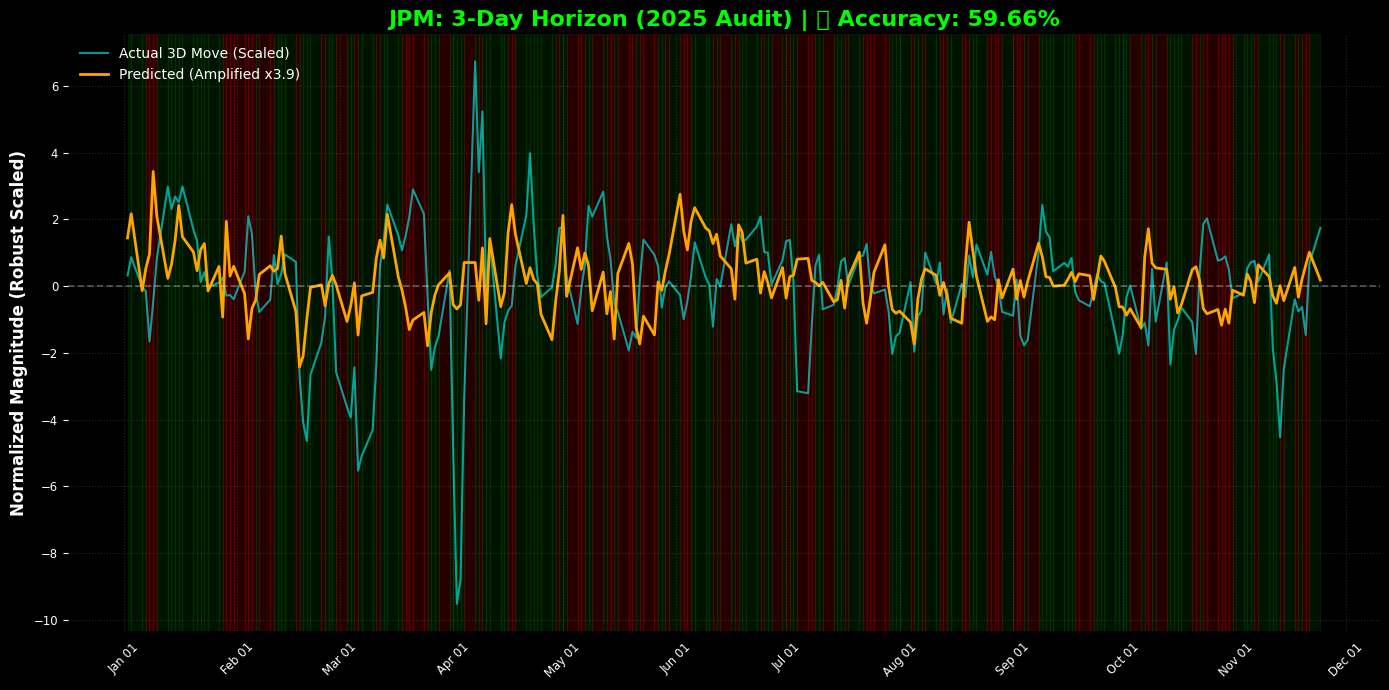

 Generating Amplified Chart (50% Power) for XOM...


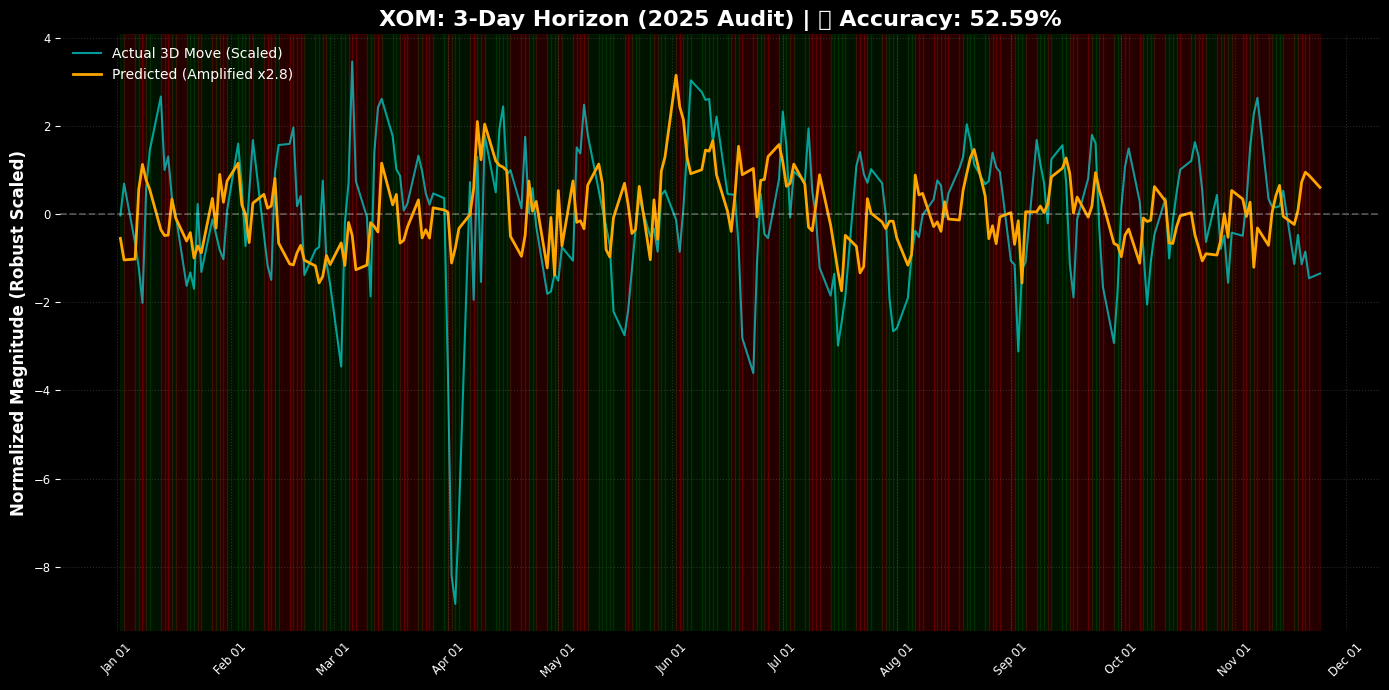

 Generating Amplified Chart (50% Power) for SPY...


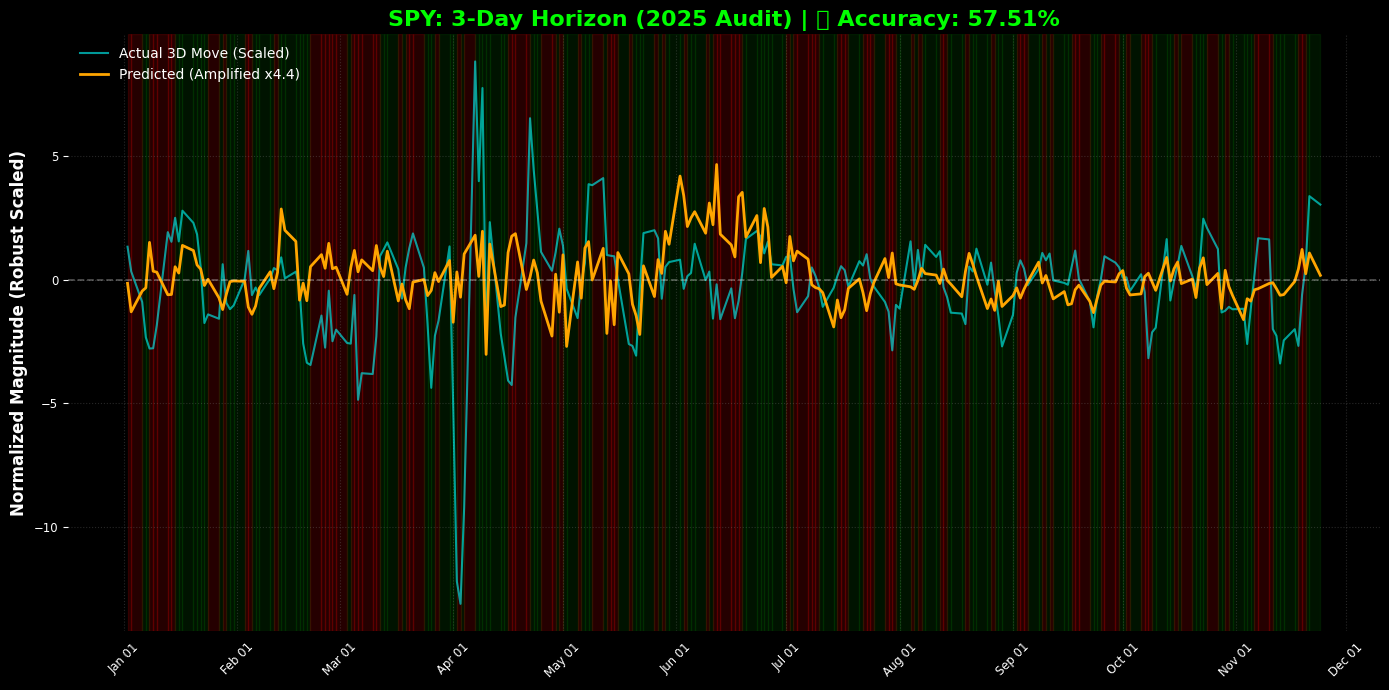

 Generating Amplified Chart (50% Power) for NVDA...


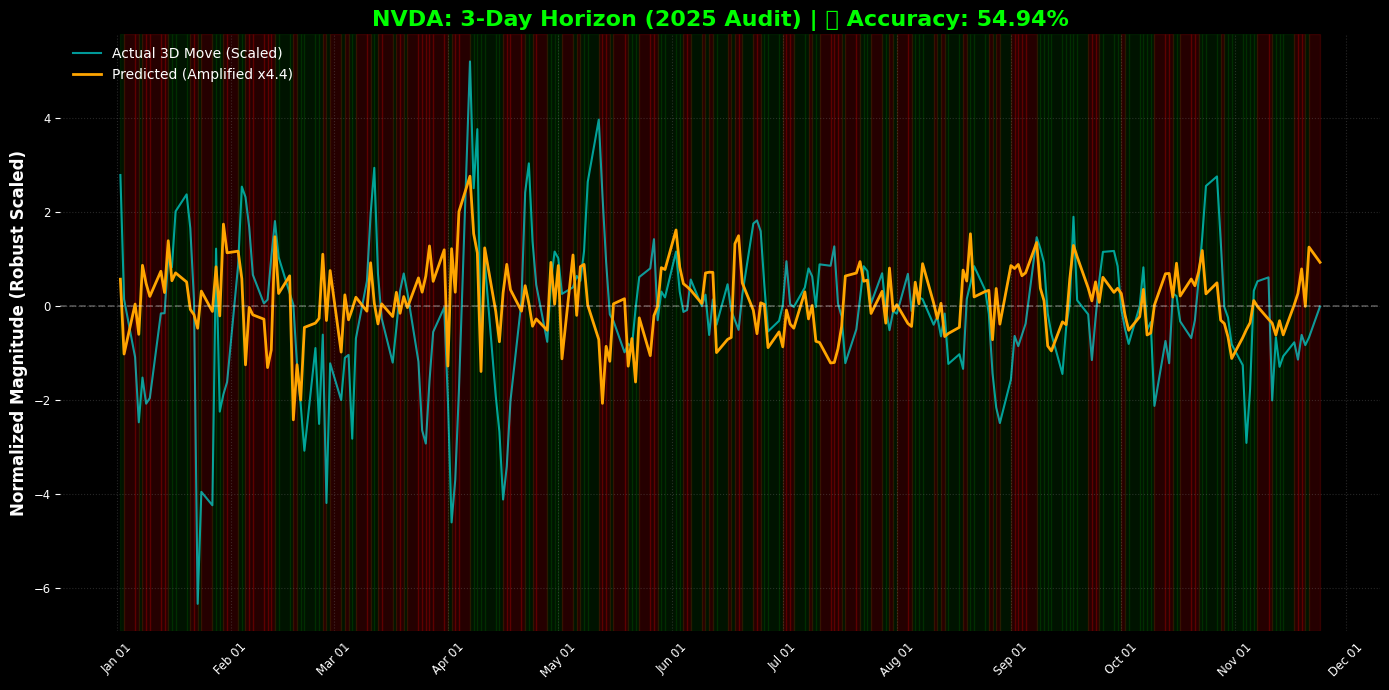

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def visualize_3d_audit(ticker, model):
    """
    Generates a 'Truth Chart' with REDUCED AUTO-MAGNIFICATION (50%).
    - Scales the 'safe' predictions up to 50% of market volatility.
    - Prints Directional Accuracy in the title.
    """
    print(f" Generating Amplified Chart (50% Power) for {ticker}...")

    try:
        # --- 1. DATA PREP ---
        df = yf.download(ticker, start="2024-06-01", end=pd.Timestamp.today(), interval="1d", progress=False)
        if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
        if df.index.tz is not None: df.index = df.index.tz_localize(None)

        # Features
        df['LogReturns'] = np.log(df['Close'] / df['Close'].shift(1))
        df['LogVol'] = np.log1p(df['Volume'])
        df['Volatility'] = df['LogReturns'].rolling(20).std().fillna(0)

        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))
        df['RSI'] = df['RSI'].fillna(50)
        df.dropna(inplace=True)

        # TimeSeries & Scaling
        ts = TimeSeries.from_dataframe(df, value_cols=['LogReturns', 'LogVol', 'Volatility', 'RSI'], fill_missing_dates=True, freq='B')
        ts = MissingValuesFiller().transform(ts).astype(np.float32)
        scaler = Scaler(RobustScaler())
        ts_scaled = scaler.fit_transform(ts)

        # Find Start Date
        valid_indices = ts_scaled.time_index[ts_scaled.time_index > TRAIN_CUTOFF]
        if len(valid_indices) == 0: return
        valid_start = valid_indices[0]

        # --- 2. FORECASTING ---
        forecasts_list = model.historical_forecasts(
            series=ts_scaled['LogReturns'],
            past_covariates=ts_scaled[['LogVol', 'Volatility', 'RSI']],
            start=valid_start,
            forecast_horizon=HORIZON,
            stride=1,
            retrain=False,
            verbose=False,
            last_points_only=False
        )

        # --- 3. ALIGNMENT ---
        dates = []
        preds = []
        actuals = []

        for f_ts in forecasts_list:
            decision_date = f_ts.start_time()

            # Sum of trajectories
            pred_move = np.sum(f_ts.values())

            try:
                actual_slice = ts_scaled['LogReturns'].slice(f_ts.start_time(), f_ts.end_time())
                if len(actual_slice) == HORIZON:
                    actual_move = np.sum(actual_slice.values())

                    dates.append(decision_date)
                    preds.append(pred_move)
                    actuals.append(actual_move)
            except:
                continue

        # --- 4. MAGNIFICATION & METRICS ---
        dates = np.array(dates)
        preds = np.array(preds)
        actuals = np.array(actuals)

        # Calculate Accuracy
        signs_match = np.sign(preds) == np.sign(actuals)
        non_zero_mask = np.sign(actuals) != 0
        if np.sum(non_zero_mask) > 0:
            accuracy = np.mean(signs_match[non_zero_mask]) * 100
        else:
            accuracy = 0

        # Calculate Magnification Factor
        # We compare the standard deviation of Actuals vs Preds
        std_actual = np.std(actuals)
        std_pred = np.std(preds)

        if std_pred > 0:
            # ⬇ THE CHANGE: Multiplied by 0.5 to reduce amplitude by half
            mag_factor = (std_actual / std_pred) * 0.5
        else:
            mag_factor = 1.0

        # Apply Magnification to Preds for Visualization
        preds_amplified = preds * mag_factor

        # --- 5. PLOTTING ---
        plt.figure(figsize=(14, 7))
        plt.style.use('dark_background')

        # Plot Actuals (Cyan)
        plt.plot(dates, actuals, color='cyan', label='Actual 3D Move (Scaled)', alpha=0.6, linewidth=1.5)

        # Plot Preds (Orange - Amplified)
        plt.plot(dates, preds_amplified, color='orange', label=f'Predicted (Amplified x{mag_factor:.1f})', linewidth=2)

        # Fill Logic
        for i in range(len(dates) - 1):
            if signs_match[i]:
                color = 'green'
                alpha = 0.15
            else:
                color = 'red'
                alpha = 0.15
            plt.axvspan(dates[i], dates[i+1], color=color, alpha=alpha)

        # Zero Line
        plt.axhline(0, color='white', linestyle='--', alpha=0.3)

        # Formatting
        title_text = f"{ticker}: 3-Day Horizon (2025 Audit) | 🎯 Accuracy: {accuracy:.2f}%"

        title_color = 'lime' if accuracy > 53 else 'white'
        if accuracy < 48: title_color = 'salmon'

        plt.title(title_text, fontsize=16, color=title_color, fontweight='bold')
        plt.ylabel("Normalized Magnitude (Robust Scaled)", fontsize=12, color='white')
        plt.legend(loc='upper left')
        plt.grid(color='gray', linestyle=':', alpha=0.3)

        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f" Could not visualize {ticker}: {e}")

# --- EXECUTE VISUALIZATION ---
print("\n" + "="*80)
print("VISUALIZING 2025 PERFORMANCE")
print("="*80)

# We use the same audit list from earlier
viz_list = ["JPM", "XOM", "SPY", "NVDA"]

for ticker in viz_list:
    visualize_3d_audit(ticker, price_model)


 PRICE ACCURACY AUDIT
 Generating Price Chart for JPM...


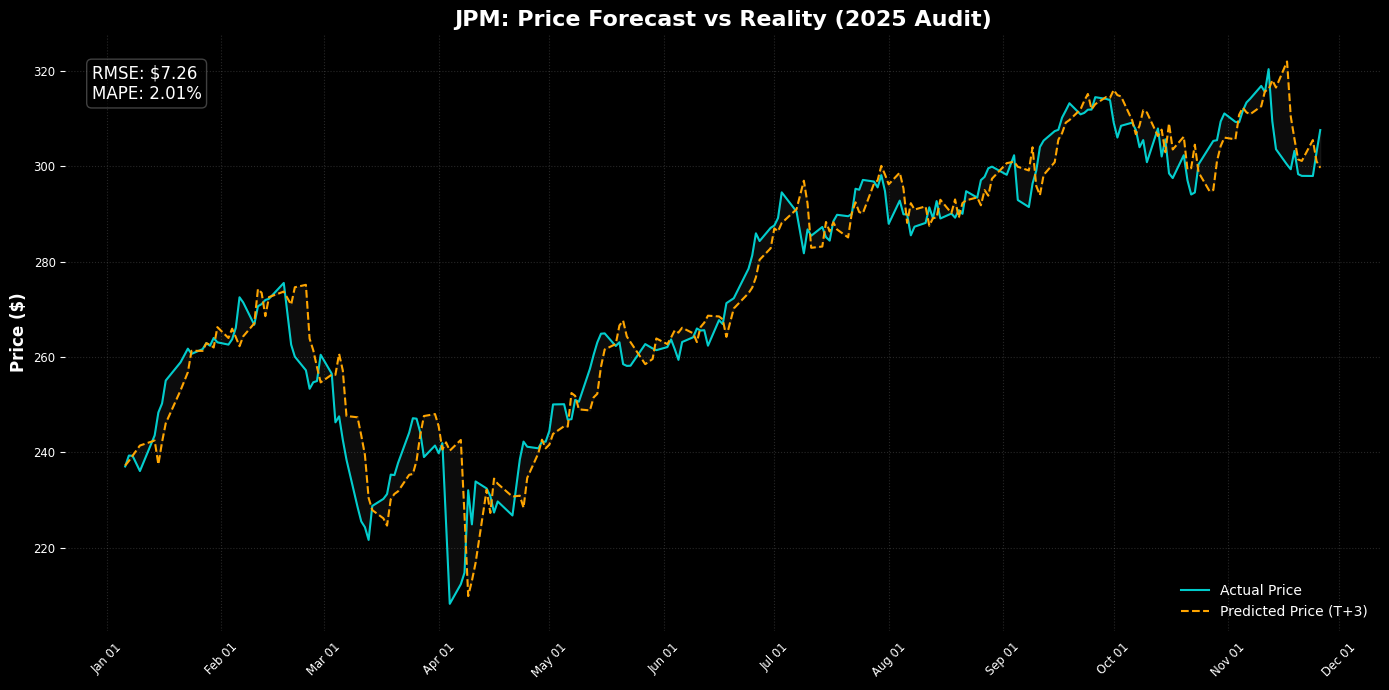

 Generating Price Chart for NVDA...


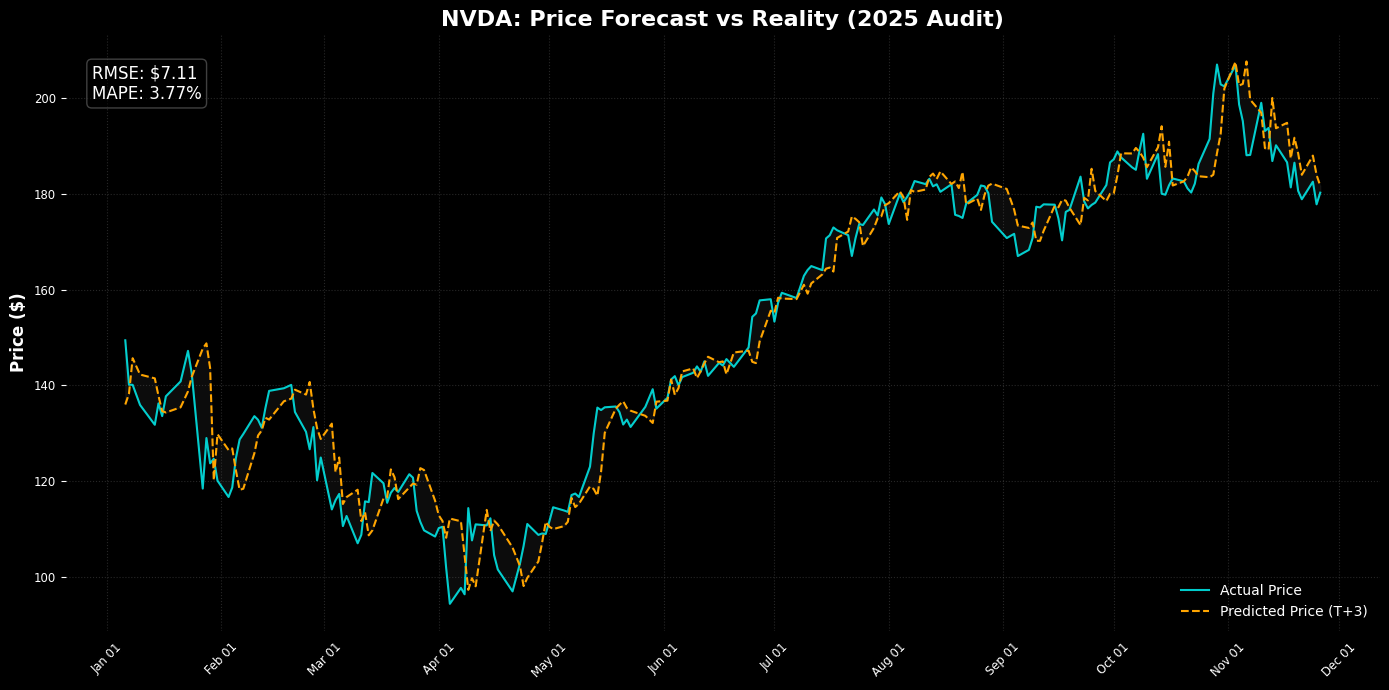

 Generating Price Chart for SPY...


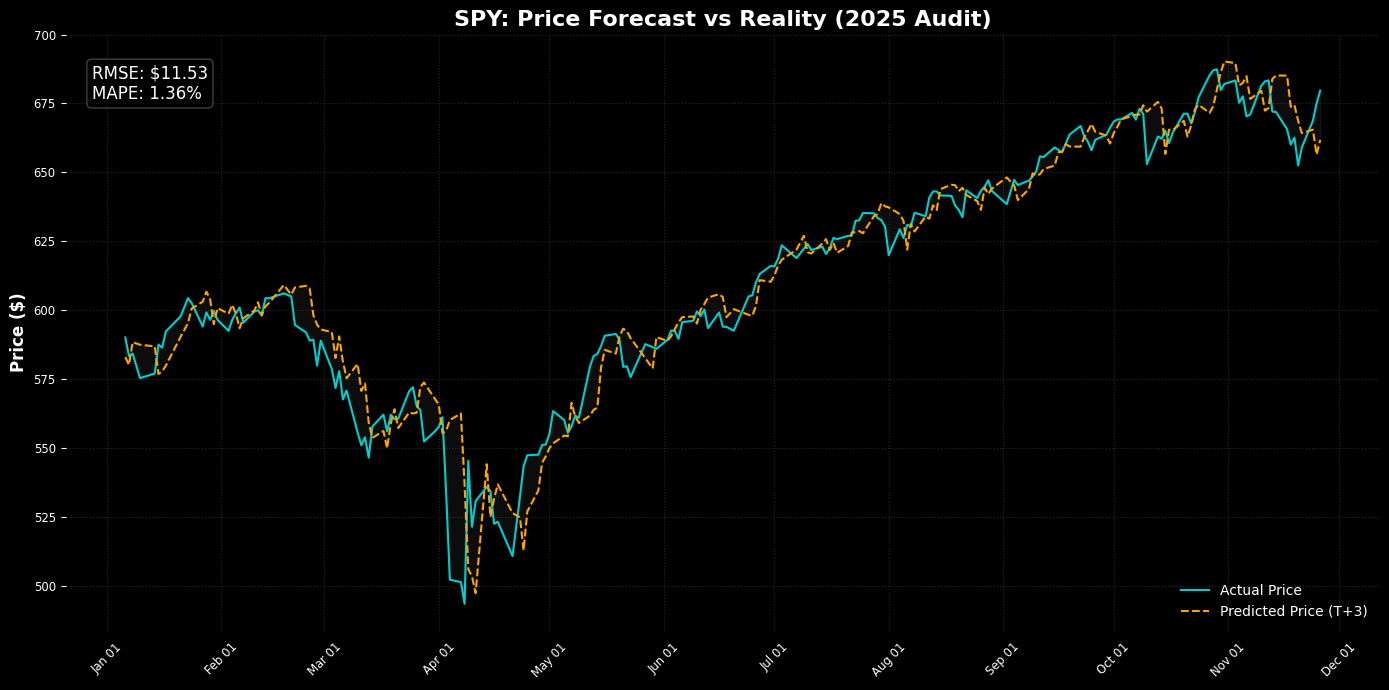

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import math

def visualize_price_forecast_with_rmse(ticker, model):
    """
    Generates a Price Chart (Actual $ vs Predicted $) for the 3-Day Horizon.
    Calculates RMSE (in $) and MAPE (in %) to grade performance.
    """
    print(f" Generating Price Chart for {ticker}...")

    try:
        # --- 1. DATA PREP ---
        # Get enough data to have a valid audit window
        df = yf.download(ticker, start="2024-06-01", end=pd.Timestamp.today(), interval="1d", progress=False)

        if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
        if df.index.tz is not None: df.index = df.index.tz_localize(None)

        # Keep a raw copy for price lookup
        raw_prices = df['Close'].copy()

        # Features
        df['LogReturns'] = np.log(df['Close'] / df['Close'].shift(1))
        df['LogVol'] = np.log1p(df['Volume'])
        df['Volatility'] = df['LogReturns'].rolling(20).std().fillna(0)

        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))
        df['RSI'] = df['RSI'].fillna(50)
        df.dropna(inplace=True)

        # TimeSeries
        ts = TimeSeries.from_dataframe(df, value_cols=['LogReturns', 'LogVol', 'Volatility', 'RSI'], fill_missing_dates=True, freq='B')
        ts = MissingValuesFiller().transform(ts).astype(np.float32)

        # Scale
        scaler_in = Scaler(RobustScaler())
        ts_scaled = scaler_in.fit_transform(ts)

        # Target Scaler (Critical for un-scaling the log returns)
        scaler_out = Scaler(RobustScaler())
        scaler_out.fit(ts['LogReturns'])

        # Start Date (Post Cutoff)
        valid_indices = ts_scaled.time_index[ts_scaled.time_index > TRAIN_CUTOFF]
        if len(valid_indices) == 0: return
        valid_start = valid_indices[0]

        # --- 2. FORECASTING ---
        forecasts_scaled = model.historical_forecasts(
            series=ts_scaled['LogReturns'],
            past_covariates=ts_scaled[['LogVol', 'Volatility', 'RSI']],
            start=valid_start,
            forecast_horizon=HORIZON,
            stride=1,
            retrain=False,
            verbose=False,
            last_points_only=False
        )

        # --- 3. PRICE RECONSTRUCTION ---
        target_dates = []
        pred_prices = []
        actual_prices = []

        for f_ts_scaled in forecasts_scaled:
            try:
                # 1. Unscale the prediction
                f_ts_inv = scaler_out.inverse_transform(f_ts_scaled)

                # 2. Calculate Cumulative Log Return (The "Trajectory")
                pred_log_sum = np.sum(f_ts_inv.values())

                # 3. Get Anchor Price (The price at the moment the prediction was made)
                # f_ts.start_time() is the first predicted step, so we need the step BEFORE that.
                # However, Darts timestamps align with the index.
                # The prediction made at T covers T+1, T+2, T+3.
                # So we look up the Close price at start_time - 1 day (conceptually).
                # Safer: Look up price at `start_time` of the forecast slice in the raw dataframe?
                # Actually, in Darts historical_forecasts, the 'start' is the first predicted time step.
                # So the Anchor is the previous business day.

                first_pred_date = f_ts_inv.start_time()
                # Find the index location of this date
                if first_pred_date not in raw_prices.index:
                    continue

                idx_loc = raw_prices.index.get_loc(first_pred_date)
                if idx_loc == 0: continue

                anchor_price = raw_prices.iloc[idx_loc - 1] # Price at T (Decision Day)

                # 4. Calculate Predicted Price at T+3
                # P_target = P_anchor * e^(sum_log_returns)
                pred_price_t3 = anchor_price * np.exp(pred_log_sum)

                # 5. Get Actual Price at T+3
                target_date = f_ts_inv.end_time()
                if target_date not in raw_prices.index:
                    continue

                actual_price_t3 = raw_prices.loc[target_date]

                target_dates.append(target_date)
                pred_prices.append(pred_price_t3)
                actual_prices.append(actual_price_t3)

            except Exception as loop_e:
                continue

        # --- 4. METRICS & PLOTTING ---
        if not target_dates:
            print(" No valid price points reconstructed.")
            return

        target_dates = np.array(target_dates)
        pred_prices = np.array(pred_prices)
        actual_prices = np.array(actual_prices)

        # Metrics
        rmse = math.sqrt(mean_squared_error(actual_prices, pred_prices))
        mape = mean_absolute_percentage_error(actual_prices, pred_prices) * 100

        # Plot
        plt.figure(figsize=(14, 7))
        plt.style.use('dark_background')

        # Plot Lines
        plt.plot(target_dates, actual_prices, color='#00FFFF', label='Actual Price', linewidth=1.5, alpha=0.8)
        plt.plot(target_dates, pred_prices, color='#FFA500', label='Predicted Price (T+3)', linewidth=1.5, linestyle='--')

        # Fill Error (The Gap)
        plt.fill_between(target_dates, actual_prices, pred_prices, color='white', alpha=0.05)

        # Annotation Box
        stats_text = f"RMSE: ${rmse:.2f}\nMAPE: {mape:.2f}%"
        props = dict(boxstyle='round', facecolor='black', alpha=0.5, edgecolor='gray')
        plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=12,
                 verticalalignment='top', color='white', bbox=props)

        # Titles
        plt.title(f"{ticker}: Price Forecast vs Reality (2025 Audit)", fontsize=16, color='white', fontweight='bold')
        plt.ylabel("Price ($)", fontsize=12, color='white')
        plt.legend(loc='lower right')
        plt.grid(color='gray', linestyle=':', alpha=0.3)

        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f" Visualization error for {ticker}: {e}")
        import traceback
        traceback.print_exc()

# --- EXECUTE ---
print("\n" + "="*80)
print(" PRICE ACCURACY AUDIT")
print("="*80)

viz_list = ["JPM", "NVDA", "SPY"]
for t in viz_list:
    visualize_price_forecast_with_rmse(t, price_model)

In [ ]:
# ==================================================================================
# SECTION 3: FINBERT MODEL TRAINING (PYTORCH VERSION + METRICS)
# ==================================================================================
import os
from sklearn.metrics import classification_report, accuracy_score
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DISABLE WANDB LOGGING
os.environ["WANDB_DISABLED"] = "true"

print("\n" + "="*80)
print(" CHECKING FINBERT MODEL STATUS (PYTORCH)")
print("="*80)

finbert_model_exists = os.path.exists(os.path.join(FINBERT_MODEL_DIR, "config.json"))

if finbert_model_exists:
    print(f" FinBERT model exists at {FINBERT_MODEL_DIR}. Loading...")
    tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL_DIR)
    sentiment_model = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL_DIR).to(device)
else:
    print(f" FinBERT model not found. Starting training...")

    if not os.path.exists(DATA_PATH_ALL):
        raise FileNotFoundError(f"❌ Please upload '{DATA_PATH_ALL}' to Colab.")

    # 1. Load Data
    print(f" Parsing {DATA_PATH_ALL}...")
    with open(DATA_PATH_ALL, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data = []
    for line in lines:
        try:
            text, label_str = line.strip().rsplit('@', 1)
            data.append({'sentence': text, 'label_str': label_str})
        except ValueError:
            continue

    df = pd.DataFrame(data)
    label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
    df['label'] = df['label_str'].map(label_map)
    df = df.dropna()
    df['label'] = df['label'].astype(int)
    print(f" Loaded {len(df)} training samples.")

    # 2. Split Data
    X_train, X_val, y_train, y_val = train_test_split(
        df['sentence'], df['label'], test_size=0.2, stratify=df['label'], random_state=42
    )

    # 3. Compute Class Weights (To handle imbalance)
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    print(f" Class Weights: {class_weights}")

    # 4. Tokenization
    tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

    train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=MAX_LEN)
    val_encodings = tokenizer(X_val.tolist(), truncation=True, padding=True, max_length=MAX_LEN)

    # 5. Create PyTorch Dataset
    class FinancialDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels.tolist()

        def __getitem__(self, idx):
            item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx])
            return item

        def __len__(self):
            return len(self.labels)

    train_dataset = FinancialDataset(train_encodings, y_train)
    val_dataset = FinancialDataset(val_encodings, y_val)

    # 6. Initialize Model
    sentiment_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT, num_labels=3
    ).to(device)

    # 7. Define Metrics Function (NEW ADDITION)
    def compute_metrics(pred):
        labels = pred.label_ids
        preds = pred.predictions.argmax(-1)

        # Calculate standard accuracy
        acc = accuracy_score(labels, preds)

        # Print detailed report to console
        print("\n" + "="*60)
        print(" CLASSIFICATION REPORT (Precision / Recall / F1)")
        print("="*60)
        print(classification_report(
            labels,
            preds,
            target_names=['Negative', 'Neutral', 'Positive'],
            digits=4
        ))
        print("="*60)

        return {'accuracy': acc}

    # 8. Custom Trainer for Weighted Loss
    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.get("labels")
            outputs = model(**inputs)
            logits = outputs.get("logits")
            loss_fct = nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
            return (loss, outputs) if return_outputs else loss

    # 9. Training Arguments
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=10,
        eval_strategy="epoch", # Evaluates at end of every epoch
        save_strategy="no"
    )

    trainer = WeightedTrainer(
        model=sentiment_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics  # <--- Linked here
    )

    # 10. Train
    print(" Starting FinBERT Training (PyTorch)...")
    trainer.train()

    # 11. Save
    print(" Saving FinBERT model...")
    sentiment_model.save_pretrained(FINBERT_MODEL_DIR)
    tokenizer.save_pretrained(FINBERT_MODEL_DIR)
    print(f" Model saved to {FINBERT_MODEL_DIR}")


 CHECKING FINBERT MODEL STATUS (PYTORCH)
 FinBERT model not found. Starting training...
 Parsing Sentences_AllAgree.txt...
 Loaded 2264 training samples.
 Class Weights: tensor([2.4945, 0.5424, 1.3238])


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

 Starting FinBERT Training (PyTorch)...
{'loss': 3.784, 'grad_norm': 22.900745391845703, 'learning_rate': 9e-07, 'epoch': 0.17543859649122806}
{'loss': 3.5508, 'grad_norm': 23.854782104492188, 'learning_rate': 1.9e-06, 'epoch': 0.3508771929824561}
{'loss': 3.2733, 'grad_norm': 42.73268127441406, 'learning_rate': 2.9e-06, 'epoch': 0.5263157894736842}
{'loss': 2.4529, 'grad_norm': 20.328357696533203, 'learning_rate': 3.9e-06, 'epoch': 0.7017543859649122}
{'loss': 1.8601, 'grad_norm': 22.98455047607422, 'learning_rate': 4.9000000000000005e-06, 'epoch': 0.8771929824561403}

 CLASSIFICATION REPORT (Precision / Recall / F1)
              precision    recall  f1-score   support

    Negative     0.3542    0.5574    0.4331        61
     Neutral     0.0000    0.0000    0.0000       278
    Positive     0.1465    0.4561    0.2217       114

    accuracy                         0.1898       453
   macro avg     0.1669    0.3378    0.2183       453
weighted avg     0.0846    0.1898    0.1141     

In [ ]:
# ==================================================================================
# SECTION 4: PREDICTION FUNCTIONS (FORMAT RESTORED)
# ==================================================================================
import datetime
from concurrent.futures import ThreadPoolExecutor

# --- Sentiment Functions ---
def predict_text(text_list, model, tokenizer, batch_size=32):
    """Predicts sentiment using batches (PyTorch Version)"""
    model.eval()
    all_preds = []
    all_probs = []
    model.to(device)

    for i in range(0, len(text_list), batch_size):
        batch = text_list[i : i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits

        probs = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=1)
        all_preds.extend(preds)
        all_probs.extend(probs)

    return np.array(all_preds), np.array(all_probs)

def fetch_yahoo_news(ticker):
    """Fetches RSS feed from Yahoo Finance"""
    try:
        rss_url = f"https://feeds.finance.yahoo.com/rss/2.0/headline?s={ticker}&region=US&lang=en-US"
        feed = feedparser.parse(rss_url)
        news_items = []
        for entry in feed.entries:
            dt = dateparser.parse(entry.published)
            if not dt: dt = datetime.datetime.now()
            news_items.append({
                'source': 'Yahoo', 'headline': entry.title, 'date': dt,
                'link': entry.link, 'publisher': 'Yahoo Finance',
                'snippet': entry.summary if 'summary' in entry else ""
            })
        return news_items
    except Exception as e:
        print(f"    Yahoo News error: {e}")
        return []

def fetch_google_news_rss(query, language='en', country='US'):
    """Fetches news from Google News RSS Feed"""
    try:
        import re
        import urllib.parse
        encoded_query = urllib.parse.quote_plus(query)
        base_url = 'https://news.google.com/rss/search'
        rss_url = f"{base_url}?q={encoded_query}&hl={language}-{country}&gl={country}&ceid={country}:{language}"
        feed = feedparser.parse(rss_url)
        news_items = []

        for entry in feed.entries:
            dt = None
            if 'published' in entry: dt = dateparser.parse(entry.published)
            elif 'published_parsed' in entry: dt = datetime.datetime(*entry.published_parsed[:6])
            if not dt: dt = datetime.datetime.now()

            source = 'Google News'
            if hasattr(entry, 'source') and 'title' in entry.source: source = entry.source['title']

            headline = entry.title
            snippet = ''
            if 'summary' in entry:
                snippet = re.sub(r'<[^>]+>', '', entry.summary)
                snippet = ' '.join(snippet.split())

            news_items.append({
                'source': 'Google', 'headline': headline, 'date': dt,
                'link': entry.link, 'publisher': source, 'snippet': snippet
            })
        return sorted(news_items, key=lambda x: x['date'], reverse=True)[:40]
    except Exception as e:
        print(f"    Google RSS error: {e}")
        return []

def calculate_initial_relevance(row, ticker, company_name, ceo_name):
    text = (str(row['headline']) + " " + str(row['snippet'])).lower()
    score = 1
    if ceo_name and ceo_name.lower() in text: score = max(score, 2)
    if company_name and company_name.lower() in text: score = max(score, 3)
    if ticker and ticker.lower() in text: score = max(score, 4)
    return score

def apply_aging(score, pub_date):
    now = datetime.datetime.now(datetime.timezone.utc)
    if pub_date.tzinfo is None: pub_date = pub_date.replace(tzinfo=datetime.timezone.utc)
    delta = now - pub_date
    days_old = max(0, delta.total_seconds() / 86400)
    decay = np.exp(-0.1 * days_old)
    return score * decay

def analyze_sentiment(ticker, company_name, ceo_name, model, tokenizer):
    """Analyzes sentiment from news sources"""
    try:
        with ThreadPoolExecutor(max_workers=2) as executor:
            future_yahoo = executor.submit(fetch_yahoo_news, ticker)
            future_google = executor.submit(fetch_google_news_rss, f"{company_name} {ticker} finance")
            yahoo_res = future_yahoo.result()
            google_res = future_google.result()

        raw_data = yahoo_res + google_res
        print(f"    News Sources: Yahoo={len(yahoo_res)} | Google={len(google_res)}")

        if not raw_data: return {'decision': 'HOLD', 'strength': 0, 'stats': {}}

        df = pd.DataFrame(raw_data)
        df['date'] = pd.to_datetime(df['date'], utc=True)
        df.drop_duplicates(subset=['headline'], keep='first', inplace=True)
        df.sort_values(by='date', ascending=False, inplace=True)

        df['initial_score'] = df.apply(lambda x: calculate_initial_relevance(x, ticker, company_name, ceo_name), axis=1)
        max_score = df['initial_score'].max() if df['initial_score'].max() > 0 else 1
        df['scaled_score'] = df['initial_score'] * (100 / max_score)
        df['final_score'] = df.apply(lambda x: apply_aging(x['scaled_score'], x['date']), axis=1)

        df['full_text'] = df['headline'].astype(str) + ". " + df['snippet'].astype(str)
        preds_idx, _ = predict_text(df['full_text'].tolist(), model, tokenizer, batch_size=32)

        df['class_id'] = preds_idx
        df['class_label'] = df['class_id'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})

        sentiment_counts = df['class_label'].value_counts()
        pos_count = sentiment_counts.get('Positive', 0)
        neu_count = sentiment_counts.get('Neutral', 0)
        neg_count = sentiment_counts.get('Negative', 0)

        print(f"    Sentiment: Positive={pos_count} | Neutral={neu_count} | Negative={neg_count}")

        score_sums = df.groupby('class_label')['final_score'].sum()
        pos_score = score_sums.get('Positive', 0)
        neu_score = score_sums.get('Neutral', 0)
        neg_score = score_sums.get('Negative', 0)

        print(f"    Scores:    Positive={pos_score:.2f} | Neutral={neu_score:.2f} | Negative={neg_score:.2f}")

        # Sentiment Logic
        if neu_score >= 1.5 * (pos_score + neg_score):
            decision, strength = "HOLD", 0
        elif pos_score > neg_score:
            decision, strength = "BUY", 2
        else:
            decision, strength = "SELL", -2

        return {
            'decision': decision, 'strength': strength,
            'stats': {'positive': pos_count, 'neutral': neu_count, 'negative': neg_count}
        }
    except Exception as e:
        print(f"    Sentiment error: {e}")
        return {'decision': 'HOLD', 'strength': 0, 'stats': {}}

# --- Price Function (Refined for Old Format Output) ---
def analyze_price_direction(ticker, model):
    """
    Predicts 3-DAY CUMULATIVE price movement using DLinear.
    Formats output to match: Price: $X -> $Y (pct%)
    """
    try:
        # Fetch 6 months to ensure 90-day Lookback is safe
        df = yf.download(ticker, period="6mo", interval="1d", progress=False)

        if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
        if df.index.tz is not None: df.index = df.index.tz_localize(None)

        if len(df) < 90:
            return {'decision': 'HOLD', 'pred_3d_pct': 0.0, 'strength': 0, 'current_price': 0, 'predicted_price': 0}

        # Features
        df['LogReturns'] = np.log(df['Close'] / df['Close'].shift(1))
        df['LogVol'] = np.log1p(df['Volume'])
        df['Volatility'] = df['LogReturns'].rolling(20).std().fillna(0)

        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))
        df['RSI'] = df['RSI'].fillna(50)
        df.dropna(inplace=True)

        current_price = df['Close'].iloc[-1]

        # Create TS
        covariates = ['LogVol', 'Volatility', 'RSI']
        ts = TimeSeries.from_dataframe(df, value_cols=['LogReturns'] + covariates, fill_missing_dates=True, freq='B')
        ts = MissingValuesFiller().transform(ts).astype(np.float32)

        # Scale
        scaler_in = Scaler(RobustScaler())
        ts_scaled = scaler_in.fit_transform(ts)

        scaler_out = Scaler(RobustScaler())
        scaler_out.fit(ts['LogReturns'])

        # Predict (Horizon=3)
        pred_scaled = model.predict(n=3, series=ts_scaled['LogReturns'], past_covariates=ts_scaled[covariates], verbose=False)

        # Decode
        pred_inv = scaler_out.inverse_transform(pred_scaled)
        log_trajectory = np.sum(pred_inv.values())
        pred_3d_pct = (np.exp(log_trajectory) - 1) * 100

        # Calculate Predicted Price based on 3D move
        predicted_price = current_price * (1 + (pred_3d_pct / 100))

        # Scoring Logic (Using 3D Thresholds)
        if pred_3d_pct > 3.0:
            decision = "STRONG BUY"
            strength = 3
        elif pred_3d_pct > 0.5:
            decision = "BUY"
            strength = 2
        elif pred_3d_pct < -3.0:
            decision = "STRONG SELL"
            strength = -3
        elif pred_3d_pct < -0.5:
            decision = "SELL"
            strength = -2
        else:
            decision = "HOLD"
            strength = 0

        # FORMATTED PRINT TO MATCH OLD STYLE
        print(f"    Price: ${current_price:.2f} → ${predicted_price:.2f} ({pred_3d_pct:+.2f}%)")

        return {
            'decision': decision,
            'pred_3d_pct': pred_3d_pct,
            'strength': strength,
            'current_price': current_price,
            'predicted_price': predicted_price
        }

    except Exception as e:
        print(f"    Price error: {e}")
        return {'decision': 'HOLD', 'pred_3d_pct': 0.0, 'strength': 0, 'current_price': 0, 'predicted_price': 0}


# ==================================================================================
# SECTION 5: UNIFIED DECISION ENGINE
# ==================================================================================

def generate_trading_signal(ticker, company_name, ceo_name):
    """
    Generates trading signal by combining Sentiment (News) + Price (3D Trajectory)
    """
    print(f"{'='*60}")
    print(f"   ANALYZING: {ticker}")
    print(f"{'='*60}")

    # Get predictions
    price_analysis = analyze_price_direction(ticker, price_model)
    sentiment_analysis = analyze_sentiment(ticker, company_name, ceo_name, sentiment_model, tokenizer)

    # Combined Score
    combined_score = price_analysis['strength'] + sentiment_analysis['strength']

    # Final Decision Logic
    if combined_score >= 4:
        final_signal = "STRONG BUY"
        emoji = "🚀"
    elif combined_score >= 1: # Lowered threshold slightly for standard Buy/Sell based on new mix
        final_signal = "BUY"
        emoji = "🟢"
    elif combined_score <= -4:
        final_signal = "STRONG SELL"
        emoji = "📉"
    elif combined_score <= -1:
        final_signal = "SELL"
        emoji = "🔴"
    else:
        final_signal = "HOLD"
        emoji = "⚪"

    return {
        'ticker': ticker,
        'signal': final_signal,
        'emoji': emoji,
        'current_price': price_analysis['current_price'],
        'predicted_price': price_analysis['predicted_price'], # Added back for display
        'pred_3d_pct': price_analysis['pred_3d_pct'],
        'combined_score': combined_score,
        'price_decision': price_analysis['decision'],
        'sentiment_decision': sentiment_analysis['decision'],
        'sentiment_stats': sentiment_analysis.get('stats', {}),
        'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }


def display_signal_report(result):
    """
    Clean display of trading signal (RESTORED OLD FORMAT)
    """
    print(f"\n{'='*60}")
    print(f"  {result['ticker']} | {result['emoji']} {result['signal']}")
    print(f"{'='*60}")
    print(f"  Price Model:     {result['price_decision']}")
    print(f"  Sentiment Model: {result['sentiment_decision']}")
    print(f"{'='*60}\n")

# ==================================================================================
# SECTION 5.5: MODEL LOADING SAFETY CHECK (ENSURE DRIVE PATHS)
# ==================================================================================

# 1. Define Paths (Matches Section 1 & 2)
DLINEAR_MODEL_PATH = os.path.join(DLINEAR_MODEL_DIR, "dlinear_model_2025_3D_Horizon.pt")

# 2. Load DLinear Price Model (If not already in memory)
if 'price_model' not in globals():
    print(f" Loading Price Model from: {DLINEAR_MODEL_PATH}")
    if os.path.exists(DLINEAR_MODEL_PATH):
        map_loc = torch.device('cpu') # Force CPU for inference
        price_model = DLinearModel.load(DLINEAR_MODEL_PATH, map_location=map_loc)
        print(" Price Model Loaded.")
    else:
        print(" Price Model NOT found. Please run Section 2.")

# 3. Load FinBERT Sentiment Model (If not already in memory)
if 'sentiment_model' not in globals() or 'tokenizer' not in globals():
    print(" Loading FinBERT Model...")
    tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
    sentiment_model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
    sentiment_model.to(device)
    print(" Sentiment Model Loaded.")

# ==================================================================================
# SECTION 6: USER INTERFACE
# ==================================================================================

# Example Run
result = generate_trading_signal("NVDA", "Nvidia", "Huang")
display_signal_report(result)

   ANALYZING: NVDA
    Price: $180.26 → $180.56 (+0.16%)
    News Sources: Yahoo=20 | Google=40
    Sentiment: Positive=12 | Neutral=40 | Negative=8
    Scores:    Positive=510.39 | Neutral=1954.05 | Negative=314.52

  NVDA | ⚪ HOLD
  Price Model:     HOLD
  Sentiment Model: HOLD

